In [1]:
import pandas as pd
import joblib
import os
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
import sys


sys.path.append(os.path.abspath(".."))
from src.utils import read_csv

In [2]:
#leemos la data limpia

df = read_csv("../data/clean/homeris-data-clean.csv")
df.head(4)

Archivo cargado existosamente desde: ../data/clean/homeris-data-clean.csv


,PERIODO,MUNICIPIO,DIAGNOSTICO,GENERO,REGIMEN,RANGO_EDAD,CANTIDAD_CASOS,ANIO,MES_NUM,PERIODO_MENSUAL,TRIMESTRE,MES_NOMBRE,SEMESTRE,GRUPO_DIAGNOSTICO,SALUD_MENTAL_CLASS
0,2024-01-01,ALCALA,OTROS TRASTORNOS DE ANSIEDAD,FEMENINO,CONTRIBUTIVO,60+,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL
1,2024-01-01,ALCALA,PROBLEMAS RELACIONADOS CON EL GRUPO PRIMARIO D...,MASCULINO,SUBSIDIADO,29-59,1,2024,1,2024-01,1,January,1,FACTORES_SOCIALES,OTROS_GRUPOS_DX
2,2024-01-01,ALCALA,RETRASO MENTAL LEVE,MASCULINO,SUBSIDIADO,12-17,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL
3,2024-01-01,ANSERMA,DORSALGIA,FEMENINO,SUBSIDIADO,29-59,1,2024,1,2024-01,1,January,1,MUSCULOESQUELETICO,OTROS_GRUPOS_DX


In [3]:
df.columns

Index(['PERIODO', 'MUNICIPIO', 'DIAGNOSTICO', 'GENERO', 'REGIMEN',
       'RANGO_EDAD', 'CANTIDAD_CASOS', 'ANIO', 'MES_NUM', 'PERIODO_MENSUAL',
       'TRIMESTRE', 'MES_NOMBRE', 'SEMESTRE', 'GRUPO_DIAGNOSTICO',
       'SALUD_MENTAL_CLASS'],
      dtype='object')

In [4]:
from src.cleaning import eliminar_cols_pp

df = eliminar_cols_pp(df)
df.head(5)

,MUNICIPIO,DIAGNOSTICO,GENERO,REGIMEN,RANGO_EDAD
0,ALCALA,OTROS TRASTORNOS DE ANSIEDAD,FEMENINO,CONTRIBUTIVO,60+
1,ALCALA,PROBLEMAS RELACIONADOS CON EL GRUPO PRIMARIO D...,MASCULINO,SUBSIDIADO,29-59
2,ALCALA,RETRASO MENTAL LEVE,MASCULINO,SUBSIDIADO,12-17
3,ANSERMA,DORSALGIA,FEMENINO,SUBSIDIADO,29-59
4,ANSERMA,ESQUIZOFRENIA,MASCULINO,CONTRIBUTIVO,29-59


In [5]:
cols = df.columns

for col in cols:
    print(f"Cantudad de valores para la variable {col}: ", len(df[col].unique()))

Cantudad de valores para la variable MUNICIPIO:  50
Cantudad de valores para la variable DIAGNOSTICO:  302
Cantudad de valores para la variable GENERO:  2
Cantudad de valores para la variable REGIMEN:  5
Cantudad de valores para la variable RANGO_EDAD:  6


| Variable | Trattamiento | Tecnica |
|--- | --- | --- |
| `MUNICIPIO` `DIAGNOSTICO` `GRUPO_DIAGNOSTICO` | Son variables nominales de alta<br>cardinalidad 50 Municipio y 302 diagnosticos | OneHot Encodig
| `GENERO` `REGIMEN` `SALUD_MENTAL_CLASS`| Son variables nominales y de baja cardinalidad | OneHot Encoding
| `RANGO_EDAD` | Es una variable de Ordinal de baja cardinalidad | OrdinalEnder

In [6]:
df['RANGO_EDAD'].unique()

array(['60+', '29-59', '12-17', '6-11', '18-28', '0-5'], dtype=object)

In [7]:
from src.preprocessing import transformar_ordinal, transformar_onehot, scaled_data
df, encoder_ord = transformar_ordinal(df)

In [8]:
from src.utils import save_artifact
help(save_artifact)

Help on function save_artifact in module src.utils:

save_artifact(obj, name, artifacts_type)
    Guarda un objeto de Python (modelo, encoder, scaler, etc.) en una subcarpeta específica
    dentro del directorio de 'artifacts'.
        Args:
            obj: obj (any): El objeto de Python que se desea persistir (ej. un modelo de KMeans o un OrdinalEncoder).
            name (str): El nombre que se le dará al archivo (sin la extensión .joblib).
            artifacts_type (str): El nombre de la subcarpeta donde se guardará.
        Returns:
            pathlib.Path: La ruta completa donde se guardó el archivo.



In [9]:
save_artifact(encoder_ord, "encoder_ord", "preprocessors")

Objeto correctamente cargado en: C:\Users\JM\Documents\Proyectos\open_data\hospital-homeris-analysis\artifacts\preprocessors\encoder_ord.joblib


WindowsPath('C:/Users/JM/Documents/Proyectos/open_data/hospital-homeris-analysis/artifacts/preprocessors/encoder_ord.joblib')

In [10]:
df.columns

Index(['MUNICIPIO', 'DIAGNOSTICO', 'GENERO', 'REGIMEN', 'RANGO_EDAD'], dtype='object')

In [11]:
df, encoder_onehot = transformar_onehot(df)

In [12]:
save_artifact(encoder_onehot, "encoder_onehot", "preprocessors")

Objeto correctamente cargado en: C:\Users\JM\Documents\Proyectos\open_data\hospital-homeris-analysis\artifacts\preprocessors\encoder_onehot.joblib


WindowsPath('C:/Users/JM/Documents/Proyectos/open_data/hospital-homeris-analysis/artifacts/preprocessors/encoder_onehot.joblib')

In [13]:
df, RScaled = scaled_data(df)

In [14]:
save_artifact(RScaled, "Rscaled", "preprocessors")

Objeto correctamente cargado en: C:\Users\JM\Documents\Proyectos\open_data\hospital-homeris-analysis\artifacts\preprocessors\Rscaled.joblib


WindowsPath('C:/Users/JM/Documents/Proyectos/open_data/hospital-homeris-analysis/artifacts/preprocessors/Rscaled.joblib')

In [15]:
from src.PCA import aplicar_PCA
df_final_pca, modelo_pca = aplicar_PCA(df, n_components=0.70)

--- Resumen PCA ---
Componentes generados: 7
Varianza total explicada: 71.46%


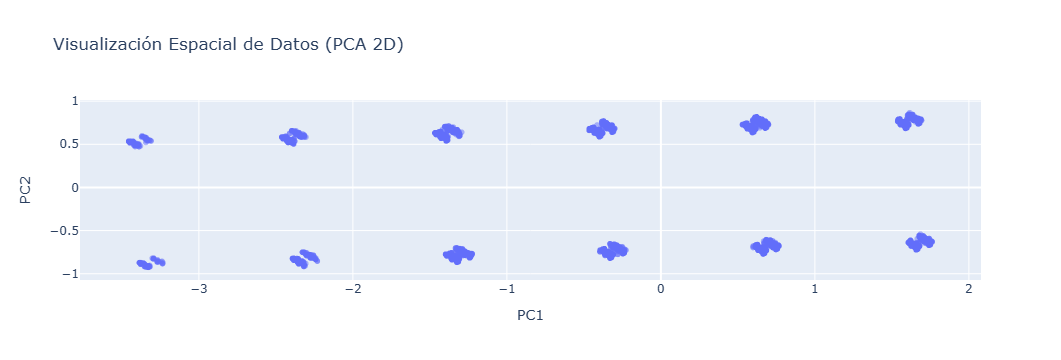

In [16]:
import plotly.express as px

# Graficamos PC1 vs PC2
fig_check = px.scatter(
    df_final_pca, 
    x='PC1', 
    y='PC2', 
    title="Visualización Espacial de Datos (PCA 2D)",
    opacity=0.5
)
fig_check.show()

Tras la codificación de 360 variables (One-Hot & Ordinal), se aplicó un análisis de componentes principales (PCA) para mitigar la "maldición de la dimensionalidad". El modelo logró condensar el 90.13% de la varianza total en solo 41 componentes, eliminando el ruido y la redundancia de las variables dispersas. La visualización en el espacio de los componentes principales (PC1 vs PC2) revela una estructura clara de "islas" o agrupamientos naturales, lo que valida que los datos ahora poseen una separación física suficiente para que algoritmos como K-Means puedan identificar segmentos diferenciados de pacientes de manera robusta.

In [17]:
modelo_pca

,n_components,0.7
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42
